# EEG Denoising from Sodium MRI Interference

Comparing Blind Source Seperation(ICA) - Supervised Learning (Residual U-Net) - Generative Approaches (Variational Autoencoders)

In [1]:
import mne
from mne.preprocessing import ICA
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import torch
import torch.nn.functional as F
from tqdm import tqdm
import torch.nn as nn

from vae_model import NoiseVAE
from resunet import DeepDSP_UNetRes
from datasets_inf import EEGDenoiseDatasetInf
from datasets import EEGDenoiseDataset

### Raw Data

In [2]:
raw = mne.io.read_raw_brainvision('H091/H091_scan.vhdr', preload=True)

chs = raw.info["ch_names"][0:24]
raw.pick(chs)
raw.set_annotations(None)
raw.resample(512.)
clean = raw.copy().crop(tmin=342.988, tmax=469.876)
contaminated = raw.copy().crop(tmin=469.876, tmax=1427.472)
clean.plot()
#raw.plot()

Extracting parameters from H091/H091_scan.vhdr...
Setting channel info structure...


C:\Users\npras\AppData\Local\Temp\ipykernel_52620\3721789839.py:1: RuntimeWarning: No coordinate information found for channels ['M1', 'M2', 'EMG1', 'EMG2', 'EMG3', 'ECG']. Setting channel types to misc. To avoid this warning, set channel types explicitly.
  raw = mne.io.read_raw_brainvision('H091/H091_scan.vhdr', preload=True)


Reading 0 ... 23571299  =      0.000 ...  4714.260 secs...


C:\Users\npras\AppData\Local\Temp\ipykernel_52620\3721789839.py:1: RuntimeWarning: Not setting positions of 6 misc channels found in montage:
['M1', 'M2', 'EMG1', 'EMG2', 'EMG3', 'ECG']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  raw = mne.io.read_raw_brainvision('H091/H091_scan.vhdr', preload=True)


Using qt as 2D backend.


Channels marked as bad:
none


In [3]:
contaminated.plot()

Channels marked as bad:
none


### Watermelon Data

In [26]:
watermelon = mne.io.read_raw_brainvision('watermelon2.0/watermelon2.0_scan.vhdr', preload=True)

chs = watermelon.info["ch_names"][0:24]
watermelon.crop(tmin=1855.415, tmax=2813.099)
watermelon.pick(chs)
watermelon.set_annotations(None)
watermelon = watermelon.copy().filter(l_freq=0.5, h_freq=None, verbose=False)
watermelon.resample(512.)
#watermelon.plot()

Extracting parameters from watermelon2.0/watermelon2.0_scan.vhdr...
Setting channel info structure...
Reading 0 ... 17386799  =      0.000 ...  3477.360 secs...


C:\Users\npras\AppData\Local\Temp\ipykernel_28008\255426313.py:1: RuntimeWarning: No coordinate information found for channels ['EMG1', 'EMG2', 'EMG3', 'ECG']. Setting channel types to misc. To avoid this warning, set channel types explicitly.
  watermelon = mne.io.read_raw_brainvision('watermelon2.0/watermelon2.0_scan.vhdr', preload=True)
C:\Users\npras\AppData\Local\Temp\ipykernel_28008\255426313.py:1: RuntimeWarning: Not setting positions of 4 misc channels found in montage:
['EMG1', 'EMG2', 'EMG3', 'ECG']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  watermelon = mne.io.read_raw_brainvision('watermelon2.0/watermelon2.0_scan.vhdr', preload=True)


<RawBrainVision | watermelon2.0_scan.eeg, 24 x 490334 (957.7 s), ~89.8 MiB, data loaded>

### Raw Contaminated PSD 

Effective window size : 16.000 (s)
Plotting power spectral density (dB=True).


c:\Users\np3106\EEG_Cleaning_NaMRI\.venv\Lib\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


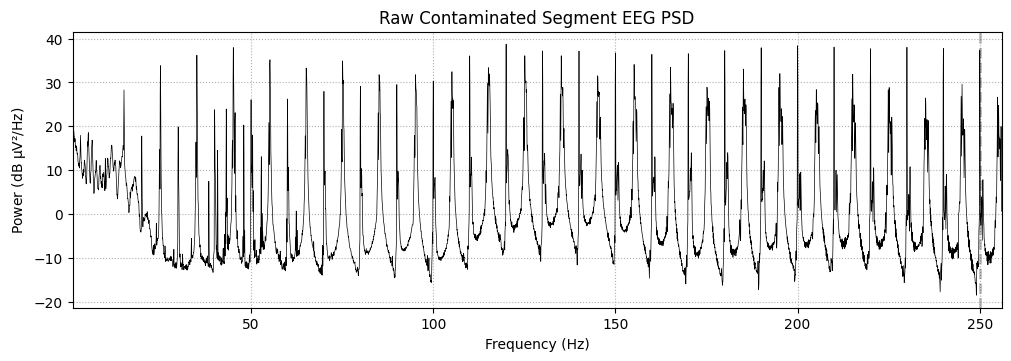

In [4]:
psd_contaminated = contaminated.compute_psd(method='welch', picks=['Fp1'], fmin=1, fmax=256, n_fft=4096*2, n_overlap=2048)
fig = psd_contaminated.plot(average=True, dB=True)
fig.axes[0].set_title("Raw Contaminated Segment EEG PSD")
plt.show()

### Raw Clean PSD

Effective window size : 16.000 (s)
Plotting power spectral density (dB=True).


c:\Users\np3106\EEG_Cleaning_NaMRI\.venv\Lib\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


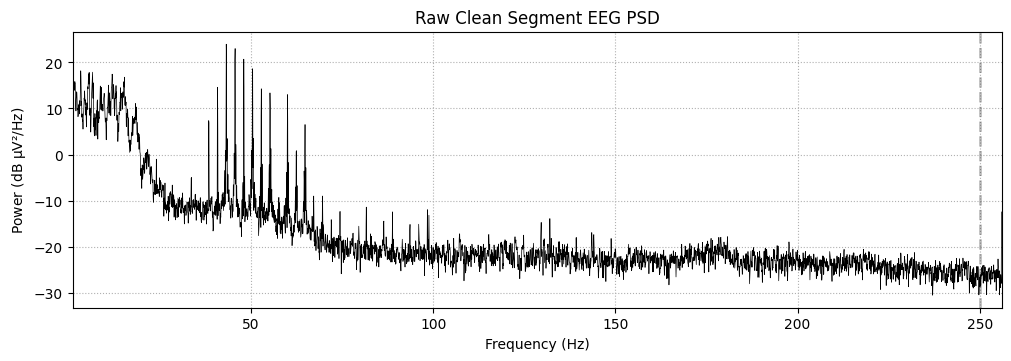

In [5]:
psd_raw_clean = clean.compute_psd(method='welch', picks=['Fp1'], fmin=1, fmax=256, n_fft=4096*2, n_overlap=2048)
fig = psd_raw_clean.plot(average=True, dB=True)
fig.axes[0].set_title("Raw Clean Segment EEG PSD")
plt.show()

### Watermelon PSD

Effective window size : 16.000 (s)
Plotting power spectral density (dB=True).


c:\Users\np3106\EEG_Cleaning_NaMRI\.venv\Lib\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


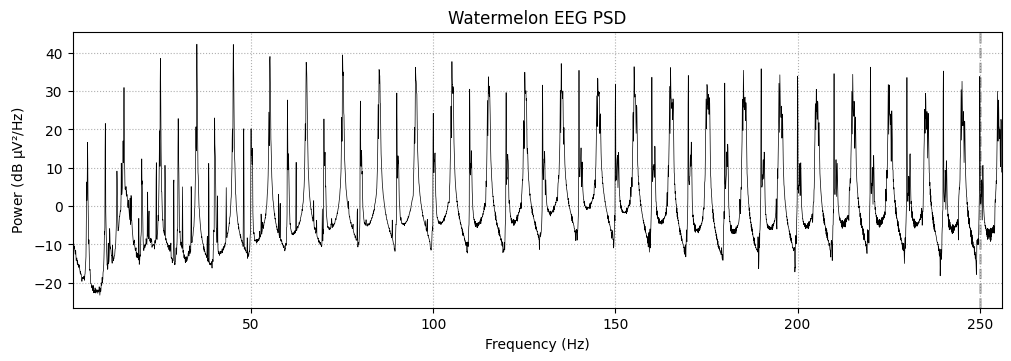

In [6]:
psd_watermelon = watermelon.compute_psd(method='welch', picks=['Fp1'], fmin=1, fmax=256, n_fft=4096*2, n_overlap=2048)
fig = psd_watermelon.plot(average=True, dB=True)
fig.axes[0].set_title("Watermelon EEG PSD")
plt.show()

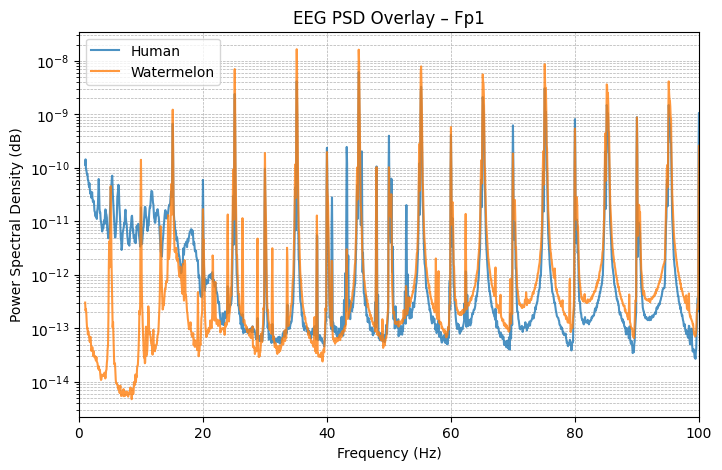

In [7]:
# Extract frequency and power values
freqs = psd_contaminated.freqs
power_contaminated = psd_contaminated.get_data().mean(axis=0)
power_watermelon = psd_watermelon.get_data().mean(axis=0)

# Plot both on the same axes (in dB)
plt.figure(figsize=(8, 5))
plt.semilogy(freqs, power_contaminated, label='Human', alpha=0.8)
plt.semilogy(freqs, power_watermelon, label='Watermelon', alpha=0.8)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density (dB)")
plt.title("EEG PSD Overlay – Fp1")
plt.legend()
plt.grid(True, which='both', ls='--', lw=0.5)
plt.xlim([0, 100])  # focus on your band of interest if you like
plt.show()


### ICA

In [20]:
filt_raw = contaminated.copy().filter(l_freq=1.0, h_freq=None)

ica = ICA(n_components=24, max_iter="auto", random_state=97)
ica.fit(filt_raw)

Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 1691 samples (3.303 s)

Fitting ICA to data using 24 channels (please be patient, this may take a while)
Selecting by number: 24 components
Fitting ICA took 19.0s.


Method,fastica
Fit parameters,algorithm=parallelfun=logcoshfun_args=Nonemax_iter=1000
Fit,29 iterations on raw data (490290 samples)
ICA components,24
Available PCA components,24
Channel types,eeg
ICA components marked for exclusion,—


### ICA components selection
We want to find the components that spectrally look more similar to the watermelon PSD plot which is to a large extent pure MRI interference

1) Compute log-PSDs

2) z-score per trace so the comparison focuses on spectral shape (not absolute power)

3) Use a mean-centered, norm-normalized dot product (i.e., cosine similarity after de-meaning), which is essentially a Pearson-like correlation of shapes.

In [27]:
def get_logpsd(inst, picks, **psd_args):
    spec = inst.compute_psd(picks=picks, **psd_args)
    psd, freqs = spec.get_data(return_freqs=True)
    return freqs, np.log(psd + 1e-12)  # (n_traces, n_freq)

def zscore_freq(logpsd):
    m  = logpsd.mean(axis=1, keepdims=True)
    sd = logpsd.std(axis=1, keepdims=True) + 1e-12
    return (logpsd - m) / sd

# 1) Watermelon template (robust): average across sensors, then z-score
fw, wm_logpsd_all = get_logpsd(watermelon, picks='eeg', method='welch', fmin=50, fmax=250, n_fft=4096*2)
wm_template = zscore_freq(wm_logpsd_all).mean(axis=0)  # 1D (n_freq,)

# 2) Human IC spectra (sources from ICA)
sources = ica.get_sources(filt_raw)
fr, ic_logpsd = get_logpsd(sources, picks='all', method='welch', fmin=50, fmax=250, n_fft=4096*2)
assert np.allclose(fr, fw)

ic_z = zscore_freq(ic_logpsd)

# 3) Rank ICs by correlation (shape); optionally combine with LSD if you want
def corr1d(a,b):
    a0, b0 = a - a.mean(), b - b.mean()
    return float(np.dot(a0,b0)/(np.linalg.norm(a0)*np.linalg.norm(b0)+1e-12))

scores = [corr1d(wm_template, ic_z[j]) for j in range(ic_z.shape[0])]
topk_idx = np.argsort(scores)[-12:][::-1]
print(topk_idx)

Effective window size : 16.000 (s)
Effective window size : 16.000 (s)
[ 9  4  0  3 20  6 10  5 11  1  7  2]


In [ ]:
#ica.plot_properties(filt_raw, picks=topk_idx);
#ica.plot_properties(filt_raw, picks=[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23]);

In [28]:
ica.exclude = topk_idx
reconst_raw = contaminated.copy()
ica.apply(reconst_raw)
reconst_raw.plot(picks='Fp1')

Applying ICA to Raw instance
    Transforming to ICA space (24 components)
    Zeroing out 12 ICA components
    Projecting back using 24 PCA components


### ICA reconstructed plot

Effective window size : 16.000 (s)


Plotting power spectral density (dB=True).


c:\Users\np3106\EEG_Cleaning_NaMRI\.venv\Lib\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


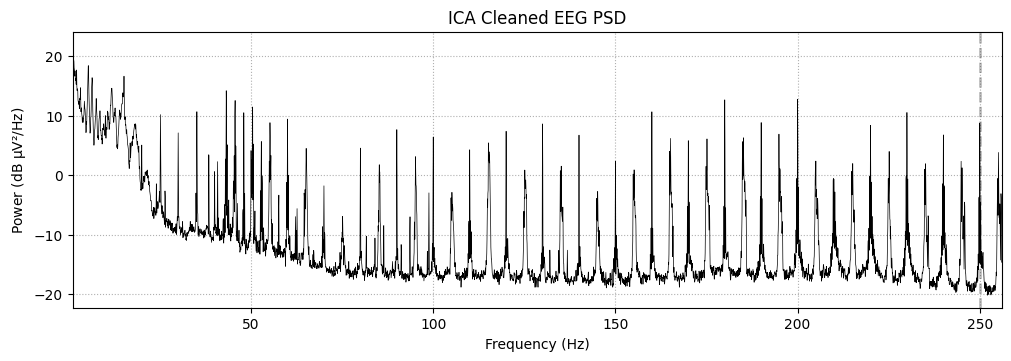

In [11]:
psd_ica_cleaned = reconst_raw.compute_psd(method='welch', picks=['Fp1'], fmin=1, fmax=256, n_fft=4096*2, n_overlap=2048)
fig = psd_ica_cleaned.plot(average=True, dB=True)
fig.axes[0].set_title("ICA Cleaned EEG PSD")
plt.show()

### Supervised Learning

Fp1
['Fp2', 'FPz', 'F3', 'F7']


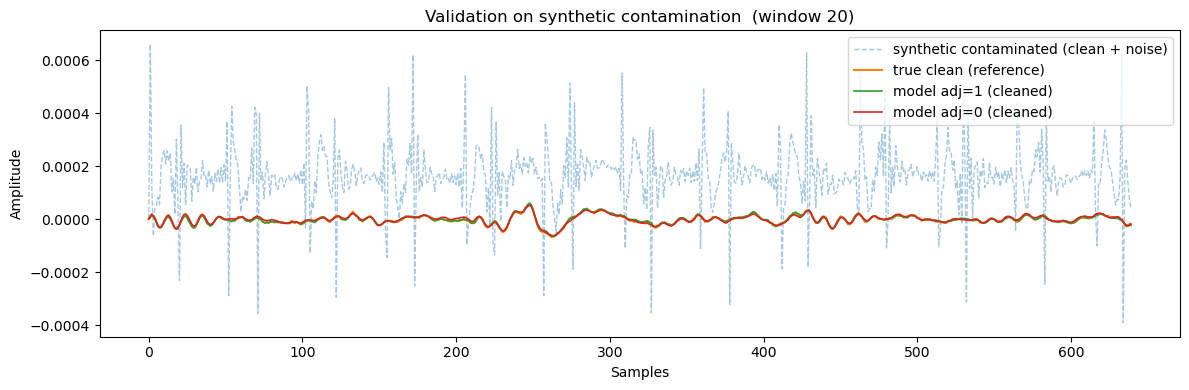

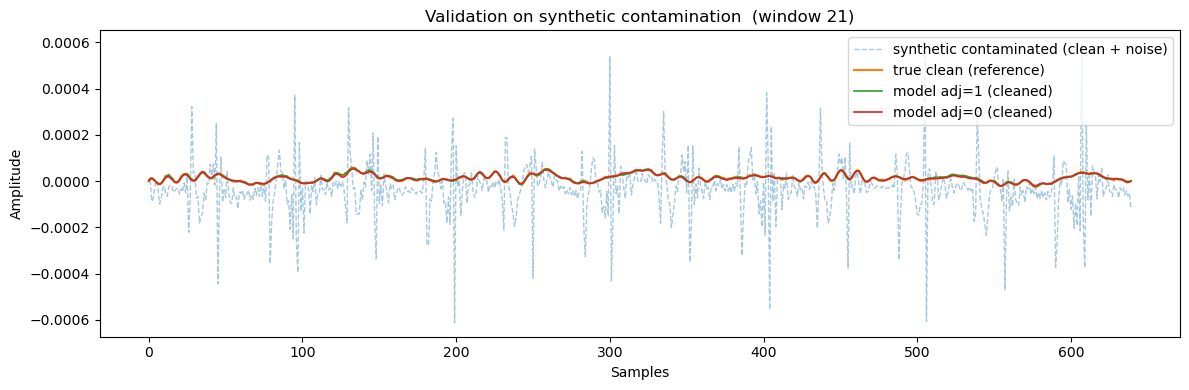

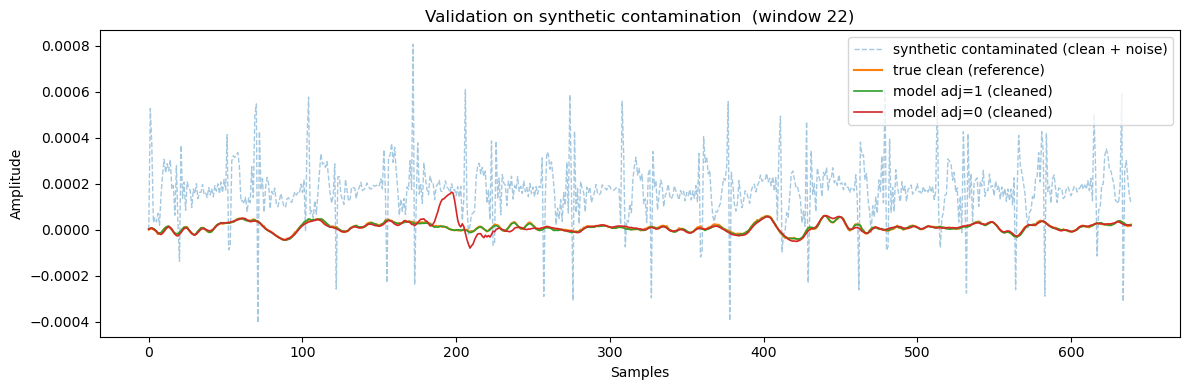

In [11]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def load_model(weight_path: str, in_channels: int) -> torch.nn.Module:
    model = DeepDSP_UNetRes(in_channels=in_channels, out_channels=1, nb=6).to(DEVICE)
    state = torch.load(weight_path, map_location="cpu")
    model.load_state_dict(state)
    model.eval()
    return model

def denorm(x, m, sd):
    return x * sd.view(1,1,1) + m.view(1,1,1)

def run_one(model, x, y, m, sd):
    """Run model, subtract predicted noise, denormalize all."""
    with torch.no_grad():
        pred_noise = model(x)
        cleaned = x[:, 0:1, :] - pred_noise
    cleaned_raw = denorm(cleaned, m, sd)
    input_raw = denorm(x, m, sd)
    y_raw = denorm(y, m, sd)
    return cleaned_raw.squeeze().cpu().numpy(), input_raw.squeeze().cpu().numpy(), y_raw.squeeze().cpu().numpy()

def plot_example(t, y_ref, cleaned_adj1, cleaned_adj0, contam, title_suffix=""):
    plt.figure(figsize=(12, 4))
    plt.plot(t, contam, lw=1, alpha=0.4, label="synthetic contaminated (clean + noise)", linestyle="--")
    plt.plot(t, y_ref, lw=1.5, label="true clean (reference)")
    plt.plot(t, cleaned_adj1, lw=1.2, label="model adj=1 (cleaned)")
    plt.plot(t, cleaned_adj0, lw=1.2, label="model adj=0 (cleaned)")
    plt.title(f"Validation on synthetic contamination{title_suffix}")
    plt.xlabel("Samples")
    plt.ylabel("Amplitude")
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

# --------------------------
# Load synthetic validation sets
# --------------------------
subj_dir = Path("data_segmented_91_10_TR_all_channels/91")
w_adj1 = "models/10_TR_unet_4_sensors.pt"
w_adj0 = "models/10_TR_unet_0_sensors.pt"

ds_adj1 = EEGDenoiseDataset(
    subj_dir,
    mode="val_syn",      # ✅ synthetic validation
    use_adjacent=True,
    split_ratio=0.9,
    seed=0,
    channels="single",
    main_channel=0,
)

ds_adj0 = EEGDenoiseDataset(
    subj_dir,
    mode="val_syn",
    use_adjacent=False,
    seed=0,
    channels="single",
    main_channel=0,
)

model_adj1 = load_model(w_adj1, in_channels=1+4)
model_adj0 = load_model(w_adj0, in_channels=1)

# --- Select example indices ---
idx_list = [20,21,22] # 42 is max
for i in idx_list:
    x1, y1, *_ , m1, sd1, _, _ = ds_adj1[i]
    x0, y0, *_ , m0, sd0, _, _ = ds_adj0[i]

    x1, y1 = x1.unsqueeze(0).to(DEVICE), y1.unsqueeze(0).to(DEVICE)
    m1, sd1 = m1.to(DEVICE), sd1.to(DEVICE)
    x0, y0 = x0.unsqueeze(0).to(DEVICE), y0.unsqueeze(0).to(DEVICE)
    m0, sd0 = m0.to(DEVICE), sd0.to(DEVICE)

    cleaned1, input1, yref1 = run_one(model_adj1, x1, y1, m1, sd1)
    cleaned0, input0, yref0 = run_one(model_adj0, x0, y0, m0, sd0)

    y_ref = yref1  # true clean
    contam = input1[0] if input1.ndim == 2 else input1
    t = np.arange(y_ref.shape[-1])

    plot_example(t, y_ref, cleaned1, cleaned0, contam, title_suffix=f"  (window {i})")


Loaded 25 channels from dataset.
EEG Channel Detected
Loaded 25 channels from dataset.
EEG Channel Detected


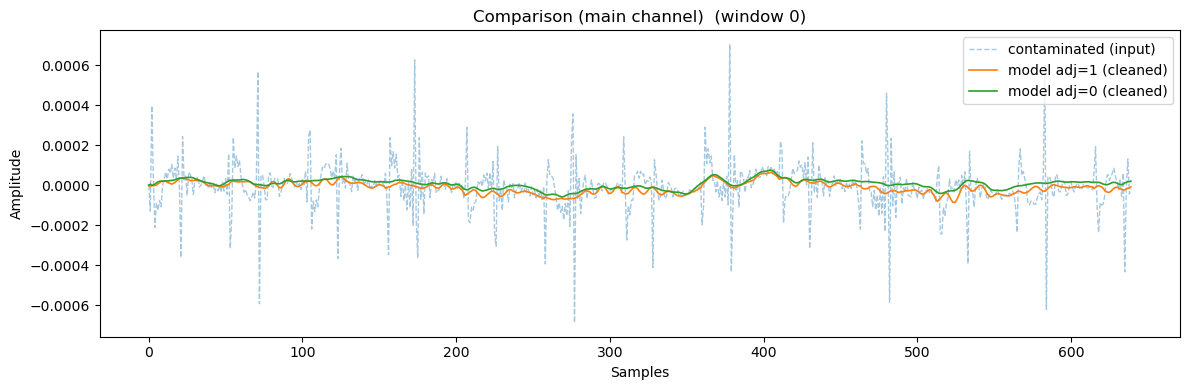

In [12]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def load_model(weight_path: str, in_channels: int) -> torch.nn.Module:
    model = DeepDSP_UNetRes(in_channels=in_channels, out_channels=1, nb=6).to(DEVICE)
    state = torch.load(weight_path, map_location="cpu")
    model.load_state_dict(state)
    model.eval()
    return model

def denorm(x, m, sd):
    # x: [1, 1, T] or [1, C, T]; m, sd: scalars as tensors
    return x * sd.view(1,1,1) + m.view(1,1,1)

def run_one(model, x, y, m, sd):
    """Run model, subtract predicted noise on main channel, denorm all."""
    with torch.no_grad():
        pred_noise = model(x)                 # [1, 1, T]
        cleaned    = x[:, 0:1, :] - pred_noise
    # denormalize
    cleaned_raw = denorm(cleaned, m, sd)      # [1, 1, T]
    input_raw   = denorm(x, m, sd)            # [1, C, T]
    y_raw       = denorm(y, m, sd)            # [1, 1, T]
    return cleaned_raw.squeeze().cpu().numpy(), input_raw.squeeze().cpu().numpy(), y_raw.squeeze().cpu().numpy()


def plot_example(t, y_ref, cleaned_adj1, cleaned_adj0, contam, title_suffix=""):
    plt.figure(figsize=(12, 4))
    plt.plot(t, contam, lw=1, alpha=0.4, label="contaminated (input)", linestyle="--")
    #plt.plot(t, y_ref, lw=1.5, label="pseudo-clean target (y)")
    plt.plot(t, cleaned_adj1, lw=1.2, label="model adj=1 (cleaned)")
    plt.plot(t, cleaned_adj0, lw=1.2, label="model adj=0 (cleaned)")
    plt.title(f"Comparison (main channel){title_suffix}")
    plt.xlabel("Samples")
    plt.ylabel("Amplitude")
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()


subj_dir = Path("data_segmented_91_10_TR_all_channels_with_ecg_interference/91")
w_adj1   = "models/10_TR_unet_4_sensors.pt"  # your model weights (adjacent sensors ON)
w_adj0   = "models/10_TR_unet_0_sensors.pt"  # your model weights (adjacent sensors OFF)

ds_adj1 = EEGDenoiseDatasetInf(
subj_dir,
use_adjacent=True,
seed=0,
channels="single",
main_channel=0,
)

ds_adj0 = EEGDenoiseDatasetInf(
subj_dir,
use_adjacent=False,
seed=0,
channels="single",
main_channel=0,
)

model_adj1 = load_model(w_adj1, in_channels=1+4)
model_adj0 = load_model(w_adj0, in_channels=1)

# --- Pick which indices to visualize ---
# e.g., first 3 windows
idx_list = [0]
for i in idx_list:
    # Fetch the SAME window index from both datasets
    # ds returns: (x, y, idx0, noise_i, m, sd, ch, real_idx)
    x1, y1, _, _, m1, sd1, _, _ = ds_adj1[i]
    x0, y0, _, _, m0, sd0, _, _ = ds_adj0[i]

    # Add batch dimension and move to device
    x1 = x1.unsqueeze(0).to(DEVICE)  # [1, C, T], C=5 if adj=1
    y1 = y1.unsqueeze(0).to(DEVICE)  # [1, 1, T]
    m1 = m1.to(DEVICE); sd1 = sd1.to(DEVICE)

    x0 = x0.unsqueeze(0).to(DEVICE)  # [1, 1, T]
    y0 = y0.unsqueeze(0).to(DEVICE)  # [1, 1, T]
    m0 = m0.to(DEVICE); sd0 = sd0.to(DEVICE)

    # --- Run both models & denormalize outputs/targets ---
    cleaned1, input1, yref1 = run_one(model_adj1, x1, y1, m1, sd1)   # cleaned1: [T], input1: [C or 1, T], yref1: [T]
    cleaned0, input0, yref0 = run_one(model_adj0, x0, y0, m0, sd0)

    # Sanity: yref1 and yref0 should be (nearly) the same waveform (different normalization paths → same denorm)
    # We'll just use yref1 as "pseudo-clean y"
    y_ref = yref1
    # Contaminated main channel is index 0 in input arrays
    contam = input1[0] if input1.ndim == 2 else input1

    # X-axis is sample index
    T = y_ref.shape[-1]
    t = np.arange(T)

    plot_example(t, y_ref, cleaned1, cleaned0, contam, title_suffix=f"  (window {i})")
    

In [29]:
sfreq = 512.0  # Hz
channel_name = 'Fp1'

def reconstruct_raw(ds, model, device, label):
    """Run inference for a given dataset+model and return MNE Raw objects."""
    cleaned_windows = []
    contaminated_windows = []

    for i in tqdm(range(len(ds)), desc=f"Running inference ({label})"):
        # Fetch window
        x, y, _, _, m, sd, _, _ = ds[i]
        x = x.unsqueeze(0).to(device)
        y = y.unsqueeze(0).to(device)
        m, sd = m.to(device), sd.to(device)

        # Run model
        cleaned, input_raw, _ = run_one(model, x, y, m, sd)

        # Handle possible shape differences
        if input_raw.ndim == 1:
            main_channel = input_raw
        else:
            main_channel = input_raw[0]

        cleaned_windows.append(np.ravel(cleaned))        # always [T]
        contaminated_windows.append(np.ravel(main_channel))

    # --- Reconstruct continuous signals ---
    cleaned_concat = np.concatenate(cleaned_windows, axis=-1)
    contaminated_concat = np.concatenate(contaminated_windows, axis=-1)

    # --- Wrap into MNE Raw objects ---
    info = mne.create_info(ch_names=[channel_name], sfreq=sfreq, ch_types='eeg')
    raw_clean = mne.io.RawArray(cleaned_concat[np.newaxis, :], info)
    raw_noisy = mne.io.RawArray(contaminated_concat[np.newaxis, :], info)

    return raw_clean, raw_noisy


# --- Run for both models ---
raw_clean_0, raw_noisy_0 = reconstruct_raw(ds_adj0, model_adj0, DEVICE, label="model0 (no adjacents)")
raw_clean_1, raw_noisy_1 = reconstruct_raw(ds_adj1, model_adj1, DEVICE, label="model1 (adjacents)")

# --- Visualize ---
print("\nDisplaying contaminated vs cleaned EEG for model0:")
raw_noisy_0.plot(title='Model 0 — Contaminated EEG', scalings='auto')
raw_clean_0.plot(title='Model 0 — Cleaned EEG', scalings='auto')

print("\nDisplaying contaminated vs cleaned EEG for model1:")
raw_noisy_1.plot(title='Model 1 — Contaminated EEG', scalings='auto')
raw_clean_1.plot(title='Model 1 — Cleaned EEG', scalings='auto')


Running inference (model0 (no adjacents)): 100%|██████████| 766/766 [00:13<00:00, 55.65it/s]

Creating RawArray with float64 data, n_channels=1, n_times=490240
    Range : 0 ... 490239 =      0.000 ...   957.498 secs
Ready.
Creating RawArray with float64 data, n_channels=1, n_times=490240
    Range : 0 ... 490239 =      0.000 ...   957.498 secs
Ready.



Running inference (model1 (adjacents)): 100%|██████████| 766/766 [00:14<00:00, 54.29it/s]

Creating RawArray with float64 data, n_channels=1, n_times=490240
    Range : 0 ... 490239 =      0.000 ...   957.498 secs
Ready.
Creating RawArray with float64 data, n_channels=1, n_times=490240
    Range : 0 ... 490239 =      0.000 ...   957.498 secs
Ready.



Displaying contaminated vs cleaned EEG for model0:

Displaying contaminated vs cleaned EEG for model1:


In [21]:
reconst_raw.plot()

Effective window size : 16.000 (s)
Plotting power spectral density (dB=True).


c:\Users\npras\miniconda3\envs\eeg_denoising_venv\Lib\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


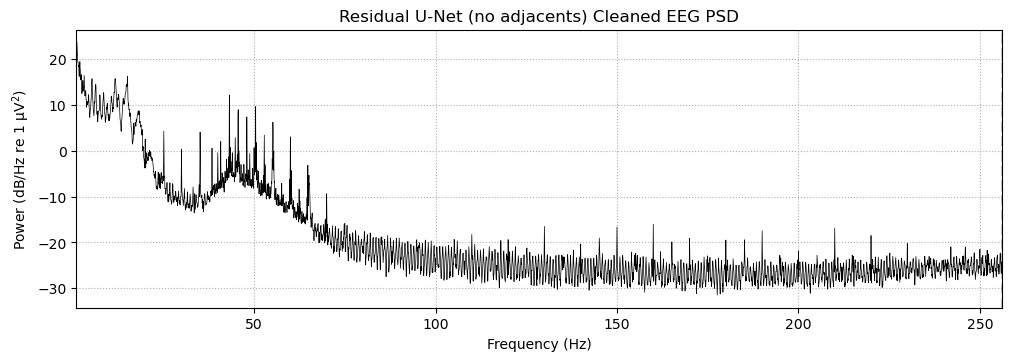

Channels marked as bad:
none
Channels marked as bad:
none
Channels marked as bad:
none
Channels marked as bad:
none


In [ ]:
psd_supervised_cleaned = raw_clean_0.compute_psd(method='welch', picks=['Fp1'], fmin=1, fmax=256, n_fft=4096*2, n_overlap=2048)
fig = psd_supervised_cleaned.plot(average=True, dB=True)
fig.axes[0].set_title("Residual U-Net (no adjacents) Cleaned EEG PSD")
plt.show()

Effective window size : 16.000 (s)
Plotting power spectral density (dB=True).


c:\Users\npras\miniconda3\envs\eeg_denoising_venv\Lib\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


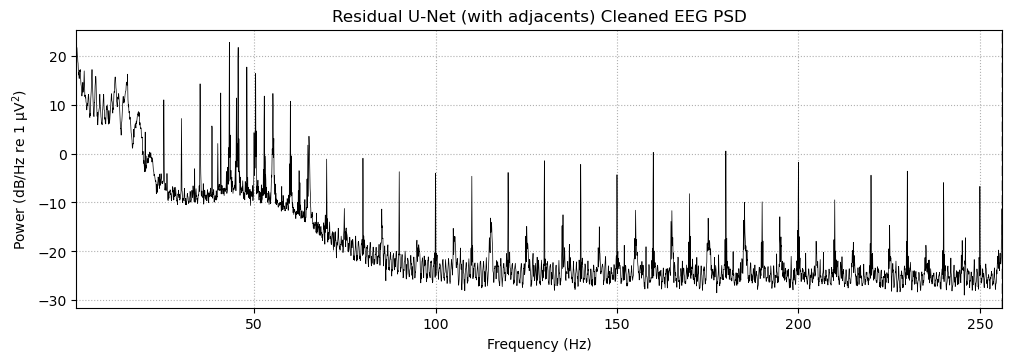

In [15]:
psd_supervised_cleaned = raw_clean_1.compute_psd(method='welch', picks=['Fp1'], fmin=1, fmax=256, n_fft=4096*2, n_overlap=2048)
fig = psd_supervised_cleaned.plot(average=True, dB=True)
fig.axes[0].set_title("Residual U-Net (with adjacents) Cleaned EEG PSD")
plt.show()

### Generative Learning

In [32]:
# ---------- device ----------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ---------- helpers ----------
def load_noise_vae(ckpt_path: str) -> NoiseVAE:
    ckpt = torch.load(ckpt_path, map_location="cpu")
    vae = NoiseVAE(T=ckpt["T"], z_dim=ckpt["z_dim"]).to(DEVICE)
    vae.load_state_dict(ckpt["state_dict"])
    vae.eval()
    for p in vae.parameters():
        p.requires_grad_(False)
    return vae

def per_window_norm_match_dataset(x: torch.Tensor, eps: float = 1e-8):
    """
    EXACT match to dataset normalization:
    m = mean(x), sd = std(x) + 1e-8  (NO CLAMP)
    x: 1D tensor [T]
    """
    m = x.mean()
    sd = x.std() + eps
    return (x - m) / sd, m, sd

def stitch_windows(windows: torch.Tensor, hop: int, crossfade: int = 0) -> torch.Tensor:
    """
    windows: [N, T]  (DENORMALIZED per window already)
    hop: hop size; for seg_overlap=0.0, hop == T
    crossfade: if non-overlap, small boundary smoothing (e.g., 32-128)
    """
    N, T = windows.shape
    if hop == T:
        if crossfade <= 0:
            return windows.reshape(-1)
        fade = min(crossfade, T // 4)
        ramp = torch.linspace(0, 1, steps=fade, device=windows.device, dtype=windows.dtype)
        out = windows[0].clone()
        for i in range(1, N):
            a = out[-fade:].clone()
            b = windows[i, :fade].clone()
            blend = a * (1 - ramp) + b * ramp
            out = torch.cat([out[:-fade], blend, windows[i, fade:]], dim=0)
        return out
    else:
        # Hann WOLA for overlap
        out_len = hop * (N - 1) + T
        acc = torch.zeros(out_len, dtype=windows.dtype, device=windows.device)
        wsum = torch.zeros_like(acc)
        win = torch.hann_window(T, periodic=False, dtype=windows.dtype, device=windows.device)
        for i in range(N):
            s = i * hop
            acc[s:s + T] += windows[i] * win
            wsum[s:s + T] += win
        wsum = torch.clamp(wsum, min=1e-8)
        return acc / wsum

def build_feature_extractor(vae: NoiseVAE, upto: int = 2) -> nn.Module:
    # Early encoder blocks only (texture/noise). Frozen.
    enc_children = list(vae.enc.children())
    upto = max(0, min(upto, len(enc_children) - 1))
    feat = nn.Sequential(*enc_children[:upto + 1]).eval().to(DEVICE)
    for p in feat.parameters():
        p.requires_grad_(False)
    return feat

def feature_loss(feature_extractor: nn.Module, x1: torch.Tensor, x2: torch.Tensor) -> torch.Tensor:
    return F.mse_loss(feature_extractor(x1), feature_extractor(x2))

def band_keep_fft_ortho(x_1d: torch.Tensor, sfreq: float, f_low: float, f_high: float) -> torch.Tensor:
    """
    Keep only [f_low, f_high] Hz using unitary FFTs (no energy scaling).
    x_1d: [T]
    """
    T = x_1d.shape[-1]
    X = torch.fft.rfft(x_1d, dim=-1, norm="ortho")
    freqs = torch.fft.rfftfreq(T, d=1.0 / sfreq).to(x_1d.device)
    mask = ((freqs >= f_low) & (freqs <= f_high)).to(X.dtype)
    X = X * mask
    return torch.fft.irfft(X, n=T, dim=-1, norm="ortho")


# ---------- MAP variants ----------
def map_estimate_noise(
    vae: NoiseVAE,
    feature_extractor: nn.Module,
    x_contam_norm: torch.Tensor,   # [1,1,T_model]
    steps: int = 300,
    lr: float = 3e-2,
    lam_z: float = 1e-2,
    lam_dc: float = 1e-4,
    lam_feat: float = 2e-3,
    alpha_recon: float = 0.5,
    init: str = "enc",
):
    with torch.no_grad():
        mu, _ = vae.encode(x_contam_norm)
    z = (mu.detach().clone() if init == "enc" else torch.zeros_like(mu))
    z.requires_grad_(True)
    opt = torch.optim.Adam([z], lr=lr)

    T_use = x_contam_norm.shape[-1]
    for _ in range(steps):
        xhat = vae.decode(z)  # [1,1,T_model]
        xhat_crop = xhat[..., :T_use]

        l1 = F.l1_loss(xhat_crop, x_contam_norm[..., :T_use])
        l2 = F.mse_loss(xhat_crop, x_contam_norm[..., :T_use])
        recon = alpha_recon * l1 + (1 - alpha_recon) * l2

        reg_z = lam_z * (z ** 2).mean()
        feat = lam_feat * feature_loss(feature_extractor, x_contam_norm[..., :T_use], xhat_crop)
        dc = lam_dc * xhat.mean(dim=[1, 2]).pow(2).mean()

        loss = recon + reg_z + feat + dc
        opt.zero_grad(); loss.backward(); opt.step()

    with torch.no_grad():
        xhat = vae.decode(z)
    return xhat, z


def map_estimate_noise_bandmatch(
    vae: NoiseVAE,
    x_contam_norm: torch.Tensor,   # [1,1,T_model]
    sfreq: float = 512.0,
    band=(20.0, 200.0),
    steps: int = 200,
    lr: float = 2e-3,
    lam_z: float = 5e-3,
    lam_dc: float = 1e-4,
    alpha: float = 0.7,
):
    """
    Optimize z so that band-passed predicted noise matches band-passed input (in normalized space).
    """
    with torch.no_grad():
        mu, _ = vae.encode(x_contam_norm)
    z = mu.detach().clone().requires_grad_(True)
    opt = torch.optim.Adam([z], lr=lr)

    T_use = x_contam_norm.shape[-1]
    x_band = band_keep_fft_ortho(x_contam_norm.squeeze(), sfreq, band[0], band[1]).view(1, 1, -1)

    for _ in range(steps):
        xhat = vae.decode(z)[..., :T_use]
        n_band = band_keep_fft_ortho(xhat.squeeze(), sfreq, band[0], band[1]).view(1, 1, -1)

        l1 = F.l1_loss(n_band, x_band)
        l2 = F.mse_loss(n_band, x_band)
        recon = alpha * l1 + (1 - alpha) * l2

        reg_z = lam_z * (z ** 2).mean()
        dc = lam_dc * xhat.mean(dim=[1, 2]).pow(2).mean()

        loss = recon + reg_z + dc
        opt.zero_grad(); loss.backward(); opt.step()

    with torch.no_grad():
        xhat = vae.decode(z)
    return xhat, z


# ---------- main sequencer ----------
def run_sequence_vae_ola(
    vae: NoiseVAE,
    T_model: int,
    windows_np: np.ndarray,        # [N, T_orig] contaminated windows (single channel)
    seg_overlap: float = 0.0,      # MUST match your segmentation
    inference_mode: str = "posterior_mean",  # 'posterior_mean' | 'map' | 'map_band'
    # MAP params (if used)
    steps: int = 150,
    lr: float = 2e-3,
    lam_z: float = 1e-2,
    lam_dc: float = 1e-4,
    lam_feat: float = 2e-3,
    alpha_recon: float = 0.5,
    feature_upto: int = 2,
    # Subtraction controls
    sfreq: float = 512.0,
    noise_band=None,               # e.g., (20.0, 200.0) or None
    scale_subtraction: bool = True,
    g_clip=(0.0, 1.25),
    crossfade_nonoverlap: int = 64,
    verbose_every: int | None = 200,
):
    assert 0.0 <= seg_overlap < 1.0
    N, T_orig = windows_np.shape
    assert T_model >= T_orig, f"T_model ({T_model}) must be >= T_orig ({T_orig})."
    hop = max(1, int(round(T_orig * (1.0 - seg_overlap))))

    feat_extractor = build_feature_extractor(vae, upto=feature_upto) if inference_mode == "map" else None

    cleaned_denorm_windows = []
    dbg_pre, dbg_post, dbg_g = [], [], []

    for i in tqdm(range(N), desc="VAE inference"):
        # to torch
        x = torch.from_numpy(windows_np[i].astype(np.float32))  # [T_orig]

        # per-window norm (MATCH dataset: no clamp)
        x_norm, m, sd = per_window_norm_match_dataset(x)
        x_norm = x_norm.to(DEVICE)

        # reflect-pad to T_model
        if T_orig != T_model:
            x_norm_pad = F.pad(x_norm.view(1, 1, -1), (0, T_model - T_orig), mode="reflect")
        else:
            x_norm_pad = x_norm.view(1, 1, -1)

        # predict NOISE in normalized space
        if inference_mode == "posterior_mean":
            with torch.no_grad():
                mu, _ = vae.encode(x_norm_pad)
                xhat_noise_norm = vae.decode(mu)                     # [1,1,T_model]
        elif inference_mode == "map":
            xhat_noise_norm, _ = map_estimate_noise(
                vae, feat_extractor, x_contam_norm=x_norm_pad,
                steps=steps, lr=lr, lam_z=lam_z, lam_dc=lam_dc,
                lam_feat=lam_feat, alpha_recon=alpha_recon, init="enc"
            )
        elif inference_mode == "map_band":
            xhat_noise_norm, _ = map_estimate_noise_bandmatch(
                vae, x_norm_pad, sfreq=sfreq, band=(noise_band or (20.0, 200.0)),
                steps=steps, lr=lr
            )
        else:
            raise ValueError("inference_mode must be 'posterior_mean', 'map', or 'map_band'")

        with torch.no_grad():
            # crop to original
            x_use = x_norm_pad[..., :T_orig].squeeze()
            n_use = xhat_noise_norm[..., :T_orig].squeeze()

            # diagnostics before gating
            pre_ratio = float((n_use.norm() / (x_use.norm() + 1e-8)).item())
            dbg_pre.append(pre_ratio)

            # optional band gate
            if noise_band is not None:
                n_gate = band_keep_fft_ortho(n_use, sfreq=sfreq, f_low=noise_band[0], f_high=noise_band[1])
            else:
                n_gate = n_use

            post_ratio = float((n_gate.norm() / (x_use.norm() + 1e-8)).item())
            dbg_post.append(post_ratio)

            # LS gain (clipped)
            num = torch.dot(n_gate.flatten(), x_use.flatten())
            den = torch.dot(n_gate.flatten(), n_gate.flatten()) + 1e-8
            g = (num / den).item() if scale_subtraction else 1.0
            g = float(np.clip(g, g_clip[0], g_clip[1]))
            dbg_g.append(g)

            if verbose_every and (i % verbose_every == 0):
                print(f"[win {i}] pre ||n||/||x||={pre_ratio:.3f}  post={post_ratio:.3f}  g={g:.3f}")

            # subtract in normalized space
            cleaned_norm = x_use - g * n_gate

            # denormalize per window
            cleaned_denorm = (cleaned_norm * sd.to(DEVICE) + m.to(DEVICE)).cpu()
            cleaned_denorm_windows.append(cleaned_denorm)

    # stack + stitch
    cleaned_denorm_windows = torch.stack(cleaned_denorm_windows, dim=0).to(DEVICE)
    if hop == T_orig:
        cleaned_full_tensor = stitch_windows(cleaned_denorm_windows, hop=hop, crossfade=int(crossfade_nonoverlap))
    else:
        cleaned_full_tensor = stitch_windows(cleaned_denorm_windows, hop=hop, crossfade=0)

    cleaned_full = cleaned_full_tensor.detach().cpu().numpy()
    cleaned_full -= cleaned_full.mean()

    print(f"[summary] mean pre-ratio={np.mean(dbg_pre):.3f}, mean post-ratio={np.mean(dbg_post):.3f}, mean g={np.mean(dbg_g):.3f}")
    return cleaned_full


# Paths (adjust to your setup)
ckpt_path = "models/noise_vae_best.pt"
subj_dir  = Path("data_segmented_91_10_TR_all_channels/91")  # must match your preprocessing
contaminated = np.load(subj_dir / "contaminated.npy", mmap_mode="r")  # [N, C, T]

# Pick channel
ch = 0
windows_np = contaminated[:, ch, :]  # [N, T_orig]

# Load VAE
vae = load_noise_vae(ckpt_path)
T_model = vae.T

# IMPORTANT: seg_overlap must match how you created these windows
cleaned_full = run_sequence_vae_ola(
    vae,
    T_model=T_model,
    windows_np=windows_np,
    seg_overlap=0.0,                    # <-- set correctly for your dataset
    inference_mode="map",    # try 'map_band' if you want band alignment
    # For 'map' tuning:
    steps=150, lr=2e-3, lam_z=1e-2, lam_dc=1e-4, lam_feat=2e-3, alpha_recon=0.5,
    feature_upto=2,
    # Subtraction knobs:
    sfreq=512.0,
    noise_band=None,                    # start with None; then try (20.0, 200.0)
    scale_subtraction=True,
    g_clip=(0.0, 1.25),
    crossfade_nonoverlap=64,
    verbose_every=200,
)

# Visualize
sfreq = 512.0
info = mne.create_info(ch_names=['Fp1'], sfreq=sfreq, ch_types='eeg')
raw_clean = mne.io.RawArray(cleaned_full[np.newaxis, :], info)
raw_clean.plot(title="EEG Denoised with VAE (posterior mean, LS-scaled)")


VAE inference:   0%|          | 1/2808 [00:01<1:10:04,  1.50s/it]

[win 0] pre ||n||/||x||=0.968  post=0.968  g=1.003


VAE inference:   7%|▋         | 201/2808 [04:25<56:40,  1.30s/it]  

[win 200] pre ||n||/||x||=0.981  post=0.981  g=1.006


VAE inference:  14%|█▍        | 401/2808 [08:51<51:10,  1.28s/it]  

...

VAE inference: 100%|█████████▉| 2801/2808 [1:05:53<00:16,  2.42s/it]

[win 2800] pre ||n||/||x||=0.987  post=0.987  g=1.006


VAE inference: 100%|██████████| 2808/2808 [1:06:10<00:00,  1.41s/it]


[summary] mean pre-ratio=0.980, mean post-ratio=0.980, mean g=1.004
Creating RawArray with float64 data, n_channels=1, n_times=1617472
    Range : 0 ... 1617471 =      0.000 ...  3159.123 secs
Ready.


Channels marked as bad:
none
Channels marked as bad:
none
Channels marked as bad:
none
Channels marked as bad:
none
Channels marked as bad:
none
Channels marked as bad:
none
Channels marked as bad:
none


{'pre_ratio': 0.9613514542579651, 'post_ratio': 0.9613514542579651, 'g': 1.009973406791687}


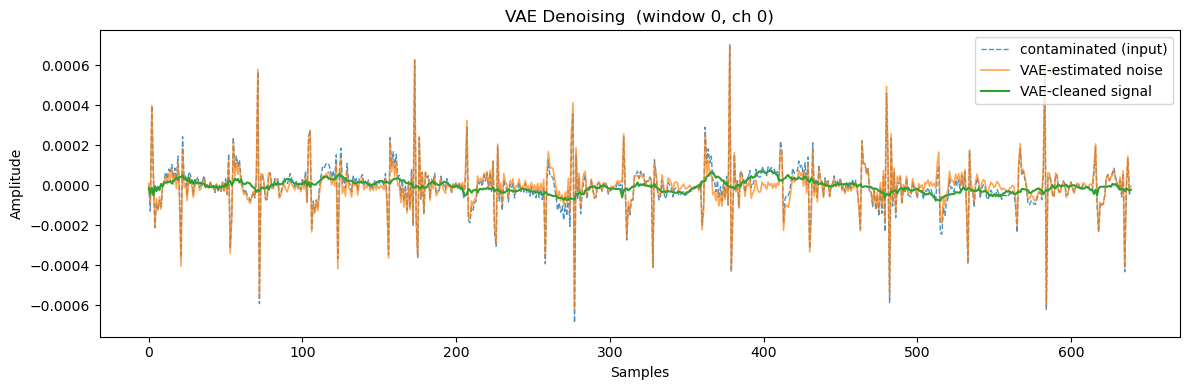

In [31]:

# ---------- device ----------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------- helpers (match training exactly) ----------
def load_noise_vae(ckpt_path: str) -> NoiseVAE:
    ckpt = torch.load(ckpt_path, map_location="cpu")
    vae = NoiseVAE(T=ckpt["T"], z_dim=ckpt["z_dim"]).to(DEVICE)
    vae.load_state_dict(ckpt["state_dict"])
    vae.eval()
    for p in vae.parameters():
        p.requires_grad_(False)
    return vae

def per_window_norm_match_dataset(x: torch.Tensor, eps: float = 1e-8):
    """
    EXACT dataset normalization: m = mean(x), sd = std(x) + 1e-8 (NO clamp).
    x: 1D [T]
    """
    m = x.mean()
    sd = x.std() + eps
    return (x - m) / sd, m, sd

def denorm(x_norm: torch.Tensor, m: torch.Tensor, sd: torch.Tensor) -> torch.Tensor:
    return x_norm * sd + m

def build_feature_extractor(vae: NoiseVAE, upto: int = 2) -> nn.Module:
    # Early encoder blocks only (texture). Frozen.
    enc_children = list(vae.enc.children())
    upto = max(0, min(upto, len(enc_children) - 1))
    feat = nn.Sequential(*enc_children[:upto + 1]).eval().to(DEVICE)
    for p in feat.parameters():
        p.requires_grad_(False)
    return feat

def feature_loss(feature_extractor: nn.Module, x1: torch.Tensor, x2: torch.Tensor) -> torch.Tensor:
    return F.mse_loss(feature_extractor(x1), feature_extractor(x2))

def band_keep_fft_ortho(x_1d: torch.Tensor, sfreq: float, f_low: float, f_high: float) -> torch.Tensor:
    """
    Keep only [f_low, f_high] Hz using unitary FFTs to avoid energy scaling.
    x_1d: [T]
    """
    T = x_1d.shape[-1]
    X = torch.fft.rfft(x_1d, dim=-1, norm="ortho")
    freqs = torch.fft.rfftfreq(T, d=1.0 / sfreq).to(x_1d.device)
    mask = ((freqs >= f_low) & (freqs <= f_high)).to(X.dtype)
    X = X * mask
    return torch.fft.irfft(X, n=T, dim=-1, norm="ortho")

# ---------- MAP variants ----------
def map_estimate_noise(
    vae: NoiseVAE,
    feature_extractor: nn.Module,          # build_feature_extractor(vae, upto=2)
    x_contam_norm: torch.Tensor,           # [1,1,T_model]
    *,
    steps: int = 300,
    lr: float = 3e-2,
    lam_z: float = 1e-2,
    lam_dc: float = 1e-4,
    lam_feat: float = 2e-3,
    alpha_recon: float = 0.5,
    init: str = "enc",
):
    """
    Training-consistent MAP:
    - crop losses to original T
    - small DC penalty
    - early-layer feature loss (small)
    """
    with torch.no_grad():
        mu, _ = vae.encode(x_contam_norm)
    z = (mu.detach().clone() if init == "enc" else torch.zeros_like(mu))
    z.requires_grad_(True)
    opt = torch.optim.Adam([z], lr=lr)

    T_use = x_contam_norm.shape[-1]
    for _ in range(steps):
        xhat = vae.decode(z)                    # [1,1,T_model]
        xhat_crop = xhat[..., :T_use]           # crop to original

        # hybrid recon on cropped region
        l1 = F.l1_loss(xhat_crop, x_contam_norm[..., :T_use])
        l2 = F.mse_loss(xhat_crop, x_contam_norm[..., :T_use])
        recon = alpha_recon * l1 + (1 - alpha_recon) * l2

        # regularizers
        reg_z = lam_z * (z ** 2).mean()
        feat  = lam_feat * feature_loss(feature_extractor, x_contam_norm[..., :T_use], xhat_crop)
        dc    = lam_dc * xhat.mean(dim=[1, 2]).pow(2).mean()

        loss = recon + reg_z + feat + dc
        opt.zero_grad(); loss.backward(); opt.step()

    with torch.no_grad():
        xhat = vae.decode(z)
    return xhat, z

def map_estimate_noise_bandmatch(
    vae: NoiseVAE,
    x_contam_norm: torch.Tensor,            # [1,1,T_model]
    *,
    sfreq: float = 512.0,
    band=(20.0, 200.0),
    steps: int = 200,
    lr: float = 2e-3,
    lam_z: float = 5e-3,
    lam_dc: float = 1e-4,
    alpha: float = 0.7,
):
    """
    Band-match MAP: match band-passed prediction to band-passed input (normalized space).
    """
    with torch.no_grad():
        mu, _ = vae.encode(x_contam_norm)
    z = mu.detach().clone().requires_grad_(True)
    opt = torch.optim.Adam([z], lr=lr)

    T_use = x_contam_norm.shape[-1]
    x_band = band_keep_fft_ortho(x_contam_norm.squeeze(), sfreq, band[0], band[1]).view(1, 1, -1)

    for _ in range(steps):
        xhat = vae.decode(z)[..., :T_use]
        n_band = band_keep_fft_ortho(xhat.squeeze(), sfreq, band[0], band[1]).view(1, 1, -1)
        l1 = F.l1_loss(n_band, x_band)
        l2 = F.mse_loss(n_band, x_band)
        recon = alpha * l1 + (1 - alpha) * l2
        reg_z = lam_z * (z ** 2).mean()
        dc    = lam_dc * xhat.mean(dim=[1, 2]).pow(2).mean()
        loss = recon + reg_z + dc
        opt.zero_grad(); loss.backward(); opt.step()

    with torch.no_grad():
        xhat = vae.decode(z)
    return xhat, z

# ---------- Single-window driver (posterior_mean / map / map_band) ----------
def run_one_vae(
    vae: NoiseVAE,
    x_contam_raw: np.ndarray,               # [T_orig], float32
    *,
    inference_mode: str = "posterior_mean", # 'posterior_mean' | 'map' | 'map_band'
    steps: int = 300, lr: float = 3e-2,
    lam_z: float = 1e-2, lam_dc: float = 1e-4, lam_feat: float = 2e-3, alpha_recon: float = 0.5,
    feature_upto: int = 2,
    sfreq: float = 512.0,
    noise_band=None,                        # e.g., (20.0, 200.0) or None
    scale_subtraction: bool = True,
    g_clip=(0.0, 1.25),
    return_debug: bool = False,
):
    """
    Returns: cleaned, noise_est, contam (all np.float32 [T_orig]) (+ optional debug dict)
    """
    T_model = vae.T
    x = torch.from_numpy(x_contam_raw).to(torch.float32).to(DEVICE)   # [T_orig]
    T_orig = x.shape[-1]

    # per-window norm (training-consistent)
    x_norm, m, sd = per_window_norm_match_dataset(x)                  # scalars for THIS window

    # reflect-pad
    if T_orig != T_model:
        x_norm_pad = F.pad(x_norm.view(1, 1, -1), (0, T_model - T_orig), mode="reflect")
    else:
        x_norm_pad = x_norm.view(1, 1, -1)

    # predict NOISE in normalized space
    if inference_mode == "posterior_mean":
        with torch.no_grad():
            mu, _ = vae.encode(x_norm_pad)
            xhat_noise_norm = vae.decode(mu)
    elif inference_mode == "map":
        feat_extractor = build_feature_extractor(vae, upto=feature_upto)
        xhat_noise_norm, _ = map_estimate_noise(
            vae, feat_extractor, x_norm_pad,
            steps=steps, lr=lr, lam_z=lam_z, lam_dc=lam_dc,
            lam_feat=lam_feat, alpha_recon=alpha_recon, init="enc"
        )
    elif inference_mode == "map_band":
        xhat_noise_norm, _ = map_estimate_noise_bandmatch(
            vae, x_norm_pad, sfreq=sfreq, band=(noise_band or (20.0, 200.0)),
            steps=steps, lr=lr
        )
    else:
        raise ValueError("inference_mode must be 'posterior_mean', 'map', or 'map_band'")

    with torch.no_grad():
        # crop to original
        x_use = x_norm_pad[..., :T_orig].squeeze()
        n_use = xhat_noise_norm[..., :T_orig].squeeze()

        pre_ratio = float((n_use.norm() / (x_use.norm() + 1e-8)).item())

        # optional band gate of predicted noise
        if noise_band is not None:
            n_gate = band_keep_fft_ortho(n_use, sfreq=sfreq, f_low=noise_band[0], f_high=noise_band[1])
        else:
            n_gate = n_use

        post_ratio = float((n_gate.norm() / (x_use.norm() + 1e-8)).item())

        # per-window LS gain
        num = torch.dot(n_gate.flatten(), x_use.flatten())
        den = torch.dot(n_gate.flatten(), n_gate.flatten()) + 1e-8
        g = (num / den).item() if scale_subtraction else 1.0
        g = float(np.clip(g, g_clip[0], g_clip[1]))

        # subtract in normalized space, then denormalize
        cleaned_norm = x_use - g * n_gate
        cleaned   = denorm(cleaned_norm, m, sd).detach().cpu().numpy().astype(np.float32)
        noise_est = denorm(n_gate,        m, sd).detach().cpu().numpy().astype(np.float32)
        contam    = x_contam_raw.astype(np.float32)

    if return_debug:
        return cleaned, noise_est, contam, {"pre_ratio": pre_ratio, "post_ratio": post_ratio, "g": g}
    return cleaned, noise_est, contam

def plot_vae_inference(t, contam, noise_est, cleaned, title_suffix=""):
    plt.figure(figsize=(12, 4))
    plt.plot(t, contam, lw=1.0, alpha=0.8, label="contaminated (input)", linestyle="--")
    plt.plot(t, noise_est, lw=1.2, label="VAE-estimated noise", alpha=0.7)
    plt.plot(t, cleaned, lw=1.5, label="VAE-cleaned signal")
    plt.title(f"VAE Denoising{title_suffix}")
    plt.xlabel("Samples")
    plt.ylabel("Amplitude")
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()


subj_dir = Path("data_segmented_91_10_TR_all_channels_with_ecg_interference/91")
vae_ckpt = "models/noise_vae_best.pt"

vae = load_noise_vae(vae_ckpt)

contaminated = np.load(subj_dir / "contaminated.npy", mmap_mode="r")  # (N, C, T)
i, ch = 0, 0
x_contam_raw = contaminated[i, ch].astype(np.float32)

cleaned, noise_est, contam, dbg = run_one_vae(
    vae, x_contam_raw,
    inference_mode="map",   # try "map_band" to align a known artifact band
    steps=300, lr=3e-2,
    lam_z=1e-2, lam_dc=1e-4, lam_feat=2e-3, alpha_recon=0.5,
    feature_upto=2,
    sfreq=512.0,
    noise_band=None,                   # e.g., (20.0, 200.0)
    scale_subtraction=True,
    g_clip=(0.0, 1.25),
    return_debug=True,
)
print(dbg)  # {'pre_ratio': ..., 'post_ratio': ..., 'g': ...}

t = np.arange(cleaned.shape[-1])
plot_vae_inference(t, contam, noise_est, cleaned, title_suffix=f"  (window {i}, ch {ch})")


Effective window size : 16.000 (s)
Plotting power spectral density (dB=True).


c:\Users\npras\miniconda3\envs\eeg_denoising_venv\Lib\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


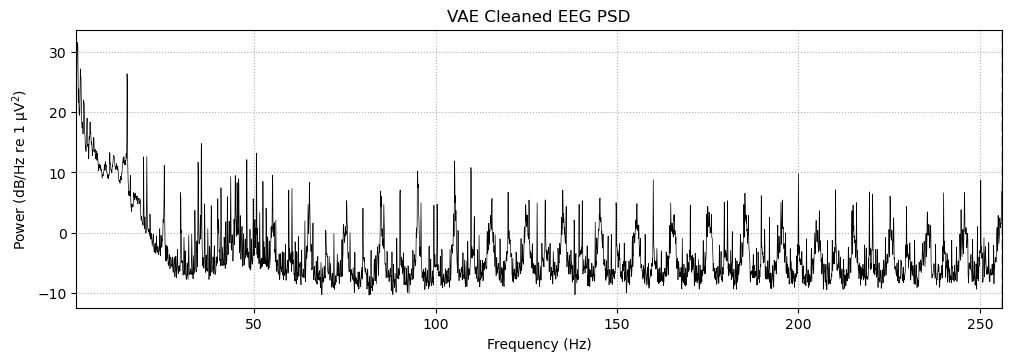

In [9]:
psd_generative_cleaned = raw_clean.compute_psd(method='welch', picks=['Fp1'], fmin=1, fmax=256, n_fft=4096*2, n_overlap=2048)
fig = psd_generative_cleaned.plot(average=True, dB=True)
fig.axes[0].set_title("VAE Cleaned EEG PSD")
plt.show()

### ECG Application

In [ ]:
ecg_raw = mne.io.read_raw_brainvision('current_study_data_raw/H091/H091_scan.vhdr', preload=True)
ecg_ch = ecg_raw.info["ch_names"][-1]
ecg_raw.pick([ecg_ch])
ecg_raw.set_annotations(None)
ecg_raw.resample(512.)
clean_ecg = ecg_raw.copy().crop(tmin=342.988, tmax=469.876)
contaminated_ecg = ecg_raw.copy().crop(tmin=469.876, tmax=1427.472)

Extracting parameters from current_study_data_raw/H092/H092_scan.vhdr...
Setting channel info structure...
Reading 0 ... 25479699  =      0.000 ...  5095.940 secs...


C:\Users\np3106\AppData\Local\Temp\ipykernel_21900\2008224519.py:1: RuntimeWarning: No coordinate information found for channels ['M1', 'M2', 'EMG1', 'EMG2', 'EMG3', 'ECG']. Setting channel types to misc. To avoid this warning, set channel types explicitly.
  ecg_raw = mne.io.read_raw_brainvision('current_study_data_raw/H092/H092_scan.vhdr', preload=True)


KeyboardInterrupt: 

In [38]:
sfreq = ecg_raw.info["sfreq"]
contaminated_ecg_data = contaminated_ecg.get_data()  # numpy array (1, T)
clean_ecg_data = clean_ecg.get_data()

# Create minimal info for this signal
info = mne.create_info(ch_names=['ECG'], sfreq=sfreq, ch_types='eeg')

# Rebuild as a new RawArray
contaminated_ecg = mne.io.RawArray(contaminated_ecg_data, info)
clean_ecg = mne.io.RawArray(clean_ecg_data, info)

Creating RawArray with float64 data, n_channels=1, n_times=490290
    Range : 0 ... 490289 =      0.000 ...   957.596 secs
Ready.
Creating RawArray with float64 data, n_channels=1, n_times=64968
    Range : 0 ... 64967 =      0.000 ...   126.889 secs
Ready.


In [22]:
clean_ecg.plot()

Channels marked as bad:
none


Effective window size : 16.000 (s)


Plotting power spectral density (dB=True).


c:\Users\np3106\EEG_Cleaning_NaMRI\.venv\Lib\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


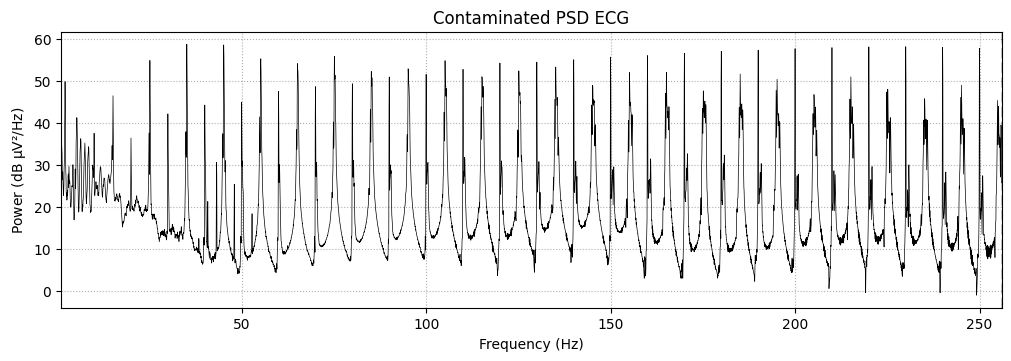

In [53]:
psd_ecg_contaminated = contaminated_ecg.compute_psd(method='welch', picks=['ECG'], fmin=1, fmax=256, n_fft=4096*2, n_overlap=2048)
fig = psd_ecg_contaminated.plot(average=True, dB=True)
fig.axes[0].set_title("Contaminated PSD ECG")
plt.show()

Effective window size : 16.000 (s)
Plotting power spectral density (dB=True).


c:\Users\np3106\EEG_Cleaning_NaMRI\.venv\Lib\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


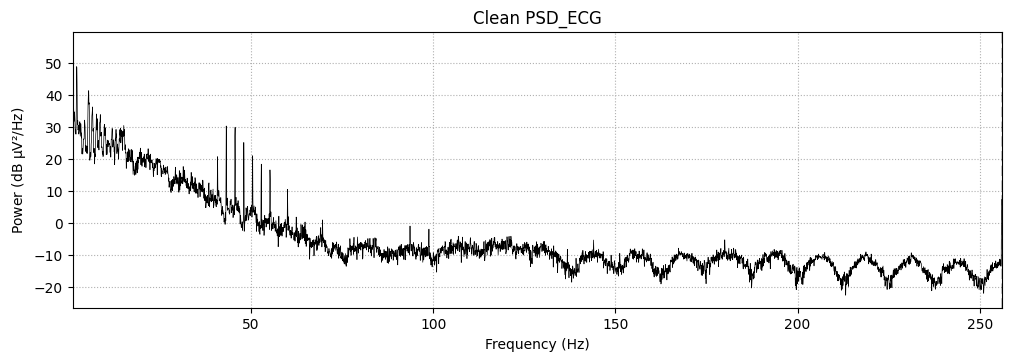

In [54]:
psd_contaminated_clean = clean_ecg.compute_psd(method='welch', picks=['ECG'], fmin=1, fmax=256, n_fft=4096*2, n_overlap=2048)
fig = psd_contaminated_clean.plot(average=True, dB=True)
fig.axes[0].set_title("Clean PSD_ECG")
plt.show()

### ECG Supervised Learning

Loaded 25 channels from dataset.
ECG Channel Detected
0


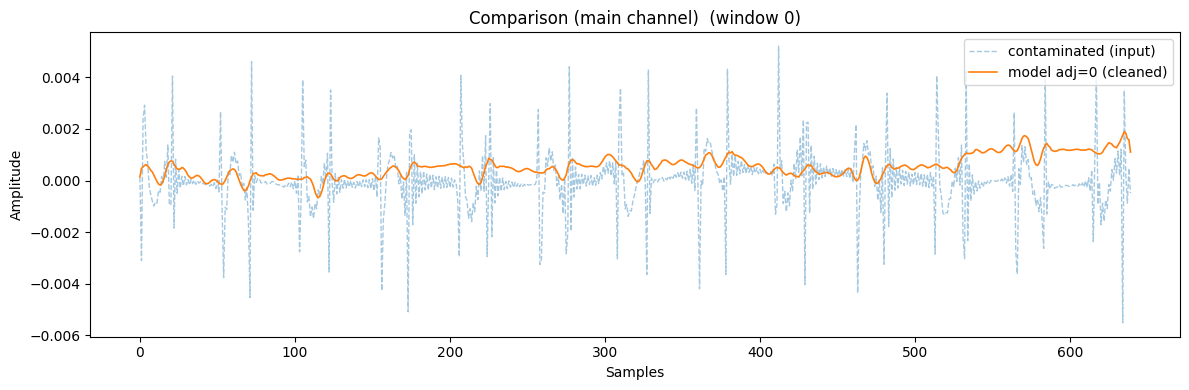

In [59]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def load_model(weight_path: str, in_channels: int) -> torch.nn.Module:
    model = DeepDSP_UNetRes(in_channels=in_channels, out_channels=1, nb=6).to(DEVICE)
    state = torch.load(weight_path, map_location="cpu")
    model.load_state_dict(state)
    model.eval()
    return model

def denorm(x, m, sd):
    # x: [1, 1, T] or [1, C, T]; m, sd: scalars as tensors
    return x * sd.view(1,1,1) + m.view(1,1,1)

def run_one(model, x, y, m, sd):
    """Run model, subtract predicted noise on main channel, denorm all."""
    with torch.no_grad():
        pred_noise = model(x)                 # [1, 1, T]
        cleaned    = x[:, 0:1, :] - pred_noise
    # denormalize
    cleaned_raw = denorm(cleaned, m, sd)      # [1, 1, T]
    input_raw   = denorm(x, m, sd)            # [1, C, T]
    y_raw       = denorm(y, m, sd)            # [1, 1, T]
    return cleaned_raw.squeeze().cpu().numpy(), input_raw.squeeze().cpu().numpy(), y_raw.squeeze().cpu().numpy()


def plot_example(t, y_ref, cleaned_adj0, contam, title_suffix=""):
    plt.figure(figsize=(12, 4))
    plt.plot(t, contam, lw=1, alpha=0.4, label="contaminated (input)", linestyle="--")
    #plt.plot(t, y_ref, lw=1.5, label="pseudo-clean target (y)")
    plt.plot(t, cleaned_adj0, lw=1.2, label="model adj=0 (cleaned)")
    plt.title(f"Comparison (main channel){title_suffix}")
    plt.xlabel("Samples")
    plt.ylabel("Amplitude")
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()


subj_dir = Path("data_segmented_91_10_TR_all_channels_with_ecg_interference/91")
w_adj0   = "models/10_TR_unet_0_sensors.pt"  # your model weights (adjacent sensors OFF)

ds_adj0 = EEGDenoiseDatasetInf(
subj_dir,
use_adjacent=True,
seed=0,
channels="single",
main_channel=24,
)

model_adj0 = load_model(w_adj0, in_channels=1)

# --- Pick which indices to visualize ---
# e.g., first 3 windows
idx_list = [0]
for i in idx_list:
    print(i)
    # Fetch the SAME window index from both datasets
    # ds returns: (x, y, idx0, noise_i, m, sd, ch, real_idx)
    x0, y0, _, _, m0, sd0, _, _ = ds_adj0[i]

    # Add batch dimension and move to device
    x0 = x0.unsqueeze(0).to(DEVICE)  # [1, 1, T]
    y0 = y0.unsqueeze(0).to(DEVICE)  # [1, 1, T]
    m0 = m0.to(DEVICE); sd0 = sd0.to(DEVICE)

    # --- Run both models & denormalize outputs/targets ---
    cleaned0, input0, yref0 = run_one(model_adj0, x0, y0, m0, sd0)

    # Sanity: yref1 and yref0 should be (nearly) the same waveform (different normalization paths → same denorm)
    # We'll just use yref1 as "pseudo-clean y"
    y_ref = yref0
    # Contaminated main channel is index 0 in input arrays
    contam = input0[0] if input0.ndim == 2 else input0

    # X-axis is sample index
    T = y_ref.shape[-1]
    t = np.arange(T)

    plot_example(t, y_ref, cleaned0, contam, title_suffix=f"  (window {i})")
    

In [61]:
sfreq = 512.0  # Hz
channel_name = 'ECG'

def reconstruct_raw(ds, model, device):
    """Run inference for a given dataset+model and return MNE Raw objects."""
    cleaned_windows = []
    contaminated_windows = []

    for i in tqdm(range(len(ds)), desc=f"Running inference"):
        # Fetch window
        x, y, _, _, m, sd, _, _ = ds[i]
        x = x.unsqueeze(0).to(device)
        y = y.unsqueeze(0).to(device)
        m, sd = m.to(device), sd.to(device)

        # Run model
        cleaned, input_raw, _ = run_one(model, x, y, m, sd)

        # Handle possible shape differences
        if input_raw.ndim == 1:
            main_channel = input_raw
        else:
            main_channel = input_raw[0]

        cleaned_windows.append(np.ravel(cleaned))        # always [T]
        contaminated_windows.append(np.ravel(main_channel))

    # --- Reconstruct continuous signals ---
    cleaned_concat = np.concatenate(cleaned_windows, axis=-1)
    contaminated_concat = np.concatenate(contaminated_windows, axis=-1)

    # --- Wrap into MNE Raw objects ---
    info = mne.create_info(ch_names=[channel_name], sfreq=sfreq, ch_types='eeg')
    raw_clean = mne.io.RawArray(cleaned_concat[np.newaxis, :], info)
    raw_noisy = mne.io.RawArray(contaminated_concat[np.newaxis, :], info)

    return raw_clean, raw_noisy


# --- Run for both models ---
raw_clean_ecg, raw_noisy_ecg = reconstruct_raw(ds_adj0, model_adj0, DEVICE)

# --- Visualize ---
print("\nDisplaying contaminated vs cleaned ECG")
raw_noisy_ecg.plot(title='Contaminated ECG', scalings='auto')
raw_clean_ecg.plot(title='Cleaned ECG', scalings='auto')

Running inference: 100%|██████████| 766/766 [00:27<00:00, 27.62it/s]

Creating RawArray with float64 data, n_channels=1, n_times=490240
    Range : 0 ... 490239 =      0.000 ...   957.498 secs
Ready.
Creating RawArray with float64 data, n_channels=1, n_times=490240
    Range : 0 ... 490239 =      0.000 ...   957.498 secs
Ready.



Displaying contaminated vs cleaned ECG


Channels marked as bad:
none
Channels marked as bad:
none
Channels marked as bad:
none


Effective window size : 16.000 (s)
Plotting power spectral density (dB=True).


c:\Users\np3106\EEG_Cleaning_NaMRI\.venv\Lib\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


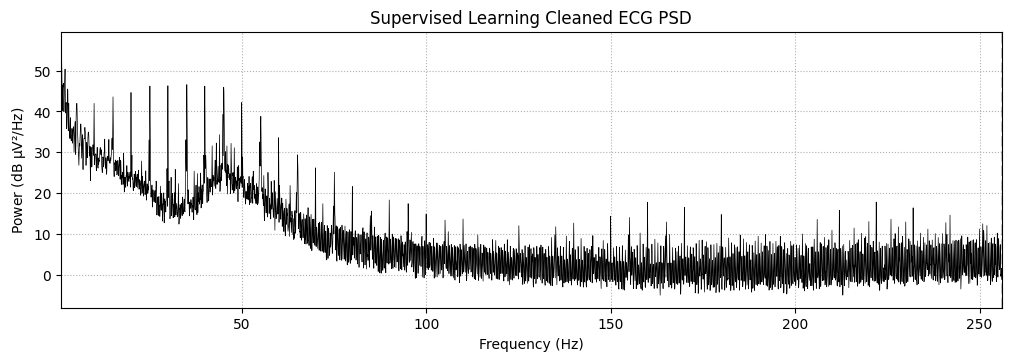

Channels marked as bad:
none


In [5]:
psd_supervised_cleaned = raw_clean_ecg.compute_psd(method='welch', picks=['ECG'], fmin=1, fmax=256, n_fft=4096*2, n_overlap=2048)
fig = psd_supervised_cleaned.plot(average=True, dB=True)
fig.axes[0].set_title("Supervised Learning Cleaned ECG PSD")
plt.show()

### Generative 

In [ ]:
def load_noise_vae(ckpt_path):
    ckpt = torch.load(ckpt_path, map_location="cpu")
    vae = NoiseVAE(T=ckpt["T"], z_dim=ckpt["z_dim"]).to(DEVICE)
    vae.load_state_dict(ckpt["state_dict"])
    vae.eval()
    for p in vae.parameters():
        p.requires_grad_(False)
    return vae

def map_estimate_noise(vae, x_contam_norm, steps=300, lr=1e-2, lam_z=1e-3, init="enc"):
    """
    x_contam_norm: [1,1,T] normalized contaminated window
    Optimize z to minimize:  L = || x_contam_norm - dec(z) ||_1 + lam_z * ||z||^2
    Returns estimated noise (normalized) and z.
    """
    with torch.no_grad():
        mu, logvar = vae.encode(x_contam_norm)
    if init == "enc":
        z = mu.detach().clone().requires_grad_(True)
    else:
        z = torch.zeros_like(mu, requires_grad=True)

    opt = torch.optim.Adam([z], lr=lr)
    for _ in range(steps):
        xhat = vae.decode(z)                         # [1,1,T]
        recon = F.l1_loss(xhat, x_contam_norm)       # match contamination structure
        reg = lam_z * torch.mean(z**2)
        loss = recon + reg
        opt.zero_grad()
        loss.backward()
        opt.step()

    with torch.no_grad():
        xhat = vae.decode(z)                         # [1,1,T]
    return xhat, z

def per_sample_norm(x):
    m = x.mean()
    sd = x.std() + 1e-8
    return (x - m) / sd, m, sd

def denorm(x, m, sd):
    return x * sd + m
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- Load model ----
ckpt_path = "models/noise_vae_0_2.pt"
vae = load_noise_vae(ckpt_path)

# ---- Load data ----
subj_dir = Path("data_segmented_91_10_TR_all_channels_interference/91")
contaminated = np.load(subj_dir / "contaminated.npy", mmap_mode="r")  # (N, C, T)

# Store results
cleaned_segments = []
noise_segments = []

# ---- Loop over windows ----
for i in tqdm(range(contaminated.shape[0]), desc="Running VAE inference"):
    cleaned_chs = []
    noise_chs = []

    for ch in range(contaminated.shape[1]):
        x_contam = contaminated[i, ch].astype(np.float32)
        x_t = torch.from_numpy(x_contam)

        # normalize per window
        x_norm, m, sd = per_sample_norm(x_t)
        x_norm = x_norm.view(1,1,-1).to(DEVICE)

        # MAP estimate noise
        xhat_noise_norm, _ = map_estimate_noise(vae, x_norm, steps=100, lr=5e-3, lam_z=1e-3, init="enc")

        # Subtract and denorm
        with torch.no_grad():
            cleaned_norm = x_norm - xhat_noise_norm
            cleaned = denorm(cleaned_norm.squeeze(), m, sd).cpu().numpy()
            noise_est = denorm(xhat_noise_norm.squeeze(), m, sd).cpu().numpy()

        cleaned_chs.append(cleaned)
        noise_chs.append(noise_est)

    cleaned_segments.append(cleaned_chs)
    noise_segments.append(noise_chs)

cleaned_segments = np.array(cleaned_segments)  # [N, C, T]
noise_segments = np.array(noise_segments)

print("Cleaned array shape:", cleaned_segments.shape)

sfreq = 512.0
info = mne.create_info(ch_names=chs, sfreq=sfreq, ch_types='eeg')

# Concatenate windows across time
cleaned_concat = np.concatenate(cleaned_segments, axis=-1)  # [C, total_T]
raw_clean = mne.io.RawArray(cleaned_concat, info)

# Visualize
raw_clean.plot(title="EEG Denoised with VAE", scalings='auto')